In [28]:
# ============================================================
# STEP 1: IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)

sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


In [29]:
# ============================================================
# STEP 2: LOAD DATASET
# ============================================================

file_path = r"D:\MSC THESIS AAVAS\AFTER MID DEFENSE\Final data with IRI\data_for_modeling_with_IRI.xlsx"

df = pd.read_excel(file_path)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

display(df.head())

Dataset loaded successfully.
Shape: (130, 10)


,SN,V85 Speed,Gradient,Radius of Curve,Carriageway Width,Left Shoulder Width,Left Shoulder Type,Right Shoulder Width,Right Shoulder Type,IRI
0,1,57.0,1.27,inf,5.5,0.9,Gravel,0.9,Gravel,3.70
1,2,33.0,2.92,46.0,5.5,0.9,Gravel,0.9,Gravel,4.51
2,3,43.0,7.97,inf,5.5,0.9,Gravel,0.9,Gravel,4.39
3,4,48.0,2.07,inf,5.5,0.9,Gravel,0.9,Gravel,4.69
4,5,36.0,1.21,16.0,5.5,0.9,Gravel,0.9,Gravel,5.57


In [30]:
# ============================================================
# STEP 3: INITIAL DATA INSPECTION
# ============================================================

print("Dataset shape:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

print("\nDataset information:")
df.info()

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

Dataset shape:
(130, 10)

Columns:
['SN', 'V85 Speed', 'Gradient', 'Radius of Curve', 'Carriageway Width', 'Left Shoulder Width', 'Left Shoulder Type', 'Right Shoulder Width', 'Right Shoulder Type', 'IRI']

First 5 rows:


,SN,V85 Speed,Gradient,Radius of Curve,Carriageway Width,Left Shoulder Width,Left Shoulder Type,Right Shoulder Width,Right Shoulder Type,IRI
0,1,57.0,1.27,inf,5.5,0.9,Gravel,0.9,Gravel,3.70
1,2,33.0,2.92,46.0,5.5,0.9,Gravel,0.9,Gravel,4.51
2,3,43.0,7.97,inf,5.5,0.9,Gravel,0.9,Gravel,4.39
3,4,48.0,2.07,inf,5.5,0.9,Gravel,0.9,Gravel,4.69
4,5,36.0,1.21,16.0,5.5,0.9,Gravel,0.9,Gravel,5.57



Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 130 entries, 0 to 129
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   SN                    130 non-null    int64  
 1   V85 Speed             130 non-null    float64
 2   Gradient              130 non-null    float64
 3   Radius of Curve       130 non-null    float64
 4   Carriageway Width     130 non-null    float64
 5   Left Shoulder Width   130 non-null    float64
 6   Left Shoulder Type    130 non-null    str    
 7   Right Shoulder Width  130 non-null    float64
 8   Right Shoulder Type   130 non-null    str    
 9   IRI                   130 non-null    float64
dtypes: float64(7), int64(1), str(2)
memory usage: 10.3 KB

Missing values:
SN                      0
V85 Speed               0
Gradient                0
Radius of Curve         0
Carriageway Width       0
Left Shoulder Width     0
Left Shoulder Type      0
Right Shoulder

In [31]:
# ============================================================
# STEP 4: CLEAN COLUMN NAMES
# ============================================================

df.columns = df.columns.str.strip()

print(df.columns.tolist())

['SN', 'V85 Speed', 'Gradient', 'Radius of Curve', 'Carriageway Width', 'Left Shoulder Width', 'Left Shoulder Type', 'Right Shoulder Width', 'Right Shoulder Type', 'IRI']


In [32]:
# ============================================================
# STEP 5: TREAT TANGENT SECTIONS
# infinity --> 1500 m
# ============================================================

radius_original = (
    df["Radius of Curve"]
    .astype(str)
    .str.strip()
    .str.lower()
)

tangent_mask = radius_original.isin(
    ["infinity", "inf", "∞"]
)

print("Number of tangent sections:")
print(tangent_mask.sum())

# Replace tangent sections
df.loc[tangent_mask, "Radius of Curve"] = 1500

# Convert radius column to numeric
df["Radius of Curve"] = pd.to_numeric(
    df["Radius of Curve"],
    errors="coerce"
)

print("\nNumber of Radius = 1500 observations:")
print((df["Radius of Curve"] == 1500).sum())

print("\nRadius summary:")
print(df["Radius of Curve"].describe())

Number of tangent sections:
46

Number of Radius = 1500 observations:
46

Radius summary:
count     130.000000
mean      595.953846
std       675.207219
min        15.000000
25%        55.000000
50%       150.000000
75%      1500.000000
max      1500.000000
Name: Radius of Curve, dtype: float64


In [33]:
# ============================================================
# STEP 6: CLEAN SHOULDER TYPE CATEGORIES
# ============================================================

df["Left Shoulder Type"] = (
    df["Left Shoulder Type"]
    .astype("string")
    .str.strip()
    .str.title()
)

df["Right Shoulder Type"] = (
    df["Right Shoulder Type"]
    .astype("string")
    .str.strip()
    .str.title()
)

print("Left Shoulder Type:")
print(df["Left Shoulder Type"].value_counts())

print("\nRight Shoulder Type:")
print(df["Right Shoulder Type"].value_counts())

Left Shoulder Type:
Left Shoulder Type
Gravel    57
Absent    41
Paved     32
Name: count, dtype: Int64

Right Shoulder Type:
Right Shoulder Type
Gravel    49
Paved     42
Absent    39
Name: count, dtype: Int64


In [34]:
# ============================================================
# STEP 7: CONVERT NUMERIC COLUMNS
# ============================================================

numeric_columns = [
    "V85 Speed",
    "Gradient",
    "Radius of Curve",
    "Carriageway Width",
    "Left Shoulder Width",
    "Right Shoulder Width",
    "IRI"
]

for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

print(df[numeric_columns].dtypes)

print("\nMissing values after conversion:")
print(df[numeric_columns].isnull().sum())

V85 Speed               float64
Gradient                float64
Radius of Curve         float64
Carriageway Width       float64
Left Shoulder Width     float64
Right Shoulder Width    float64
IRI                     float64
dtype: object

Missing values after conversion:
V85 Speed               0
Gradient                0
Radius of Curve         0
Carriageway Width       0
Left Shoulder Width     0
Right Shoulder Width    0
IRI                     0
dtype: int64


In [35]:
# ============================================================
# STEP 8: ABSOLUTE GRADIENT
# ============================================================

df["Gradient"] = df["Gradient"].abs()

print(df["Gradient"].describe())

count    130.000000
mean       3.819304
std        2.585841
min        0.100000
25%        1.365000
50%        3.625000
75%        5.975000
max       10.000000
Name: Gradient, dtype: float64


In [36]:
# ============================================================
# STEP 9: DESCRIPTIVE STATISTICS
# ============================================================

eda_variables = [
    "V85 Speed",
    "Gradient",
    "Radius of Curve",
    "Carriageway Width",
    "Left Shoulder Width",
    "Right Shoulder Width",
    "IRI"
]

descriptive_stats = (
    df[eda_variables]
    .describe()
    .T
)

display(descriptive_stats.round(3))

,count,mean,std,min,25%,50%,75%,max
V85 Speed,130.0,47.178,10.399,24.00,42.000,47.250,55.375,74.00
Gradient,130.0,3.819,2.586,0.10,1.365,3.625,5.975,10.00
Radius of Curve,130.0,595.954,675.207,15.00,55.000,150.000,1500.000,1500.00
Carriageway Width,130.0,6.247,0.949,4.70,5.390,7.000,7.000,8.00
Left Shoulder Width,130.0,0.475,0.392,0.00,0.000,0.500,0.900,1.13
Right Shoulder Width,130.0,0.484,0.386,0.00,0.000,0.500,0.900,1.18
IRI,130.0,6.991,2.253,3.63,5.060,6.865,9.152,12.05


In [37]:
# ============================================================
# STEP 10: SKEWNESS
# ============================================================

skewness = (
    df[eda_variables]
    .skew()
    .sort_values(ascending=False)
)

skewness_table = pd.DataFrame({
    "Variable": skewness.index,
    "Skewness": skewness.values
})

display(skewness_table.round(3))

,Variable,Skewness
0,Radius of Curve,0.587
1,Gradient,0.427
2,IRI,0.297
3,Left Shoulder Width,0.027
4,Right Shoulder Width,-0.016
5,V85 Speed,-0.081
6,Carriageway Width,-0.323


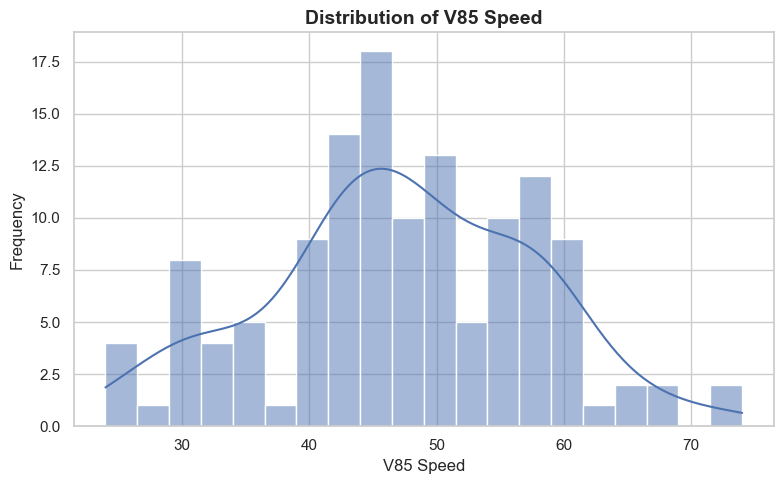

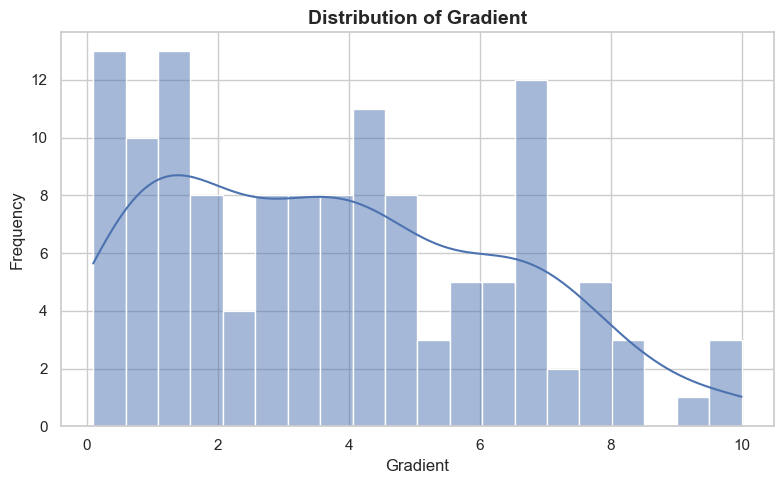

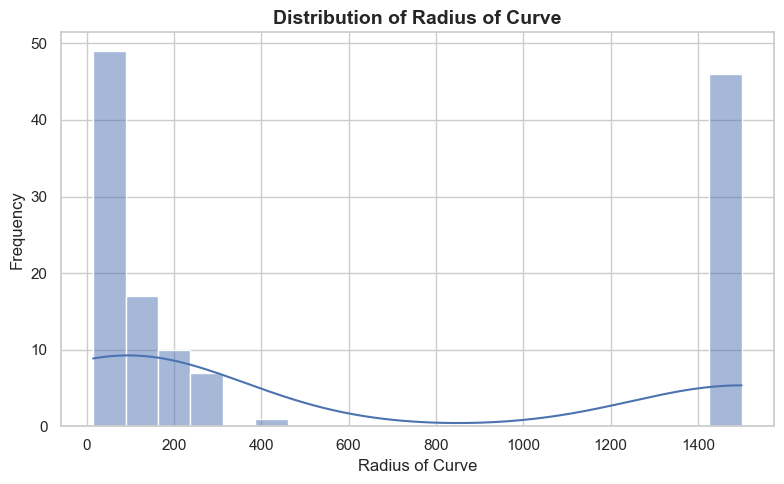

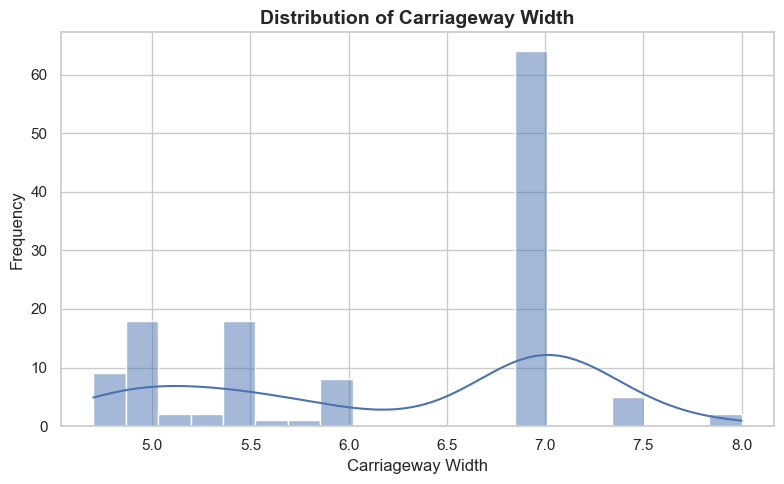

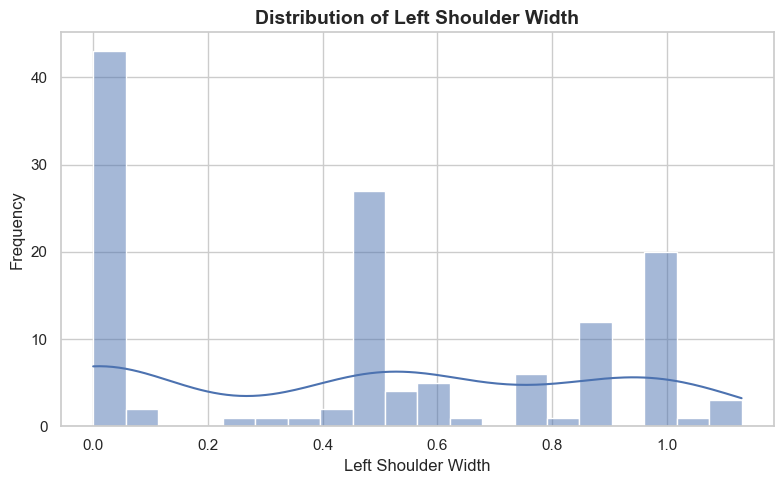

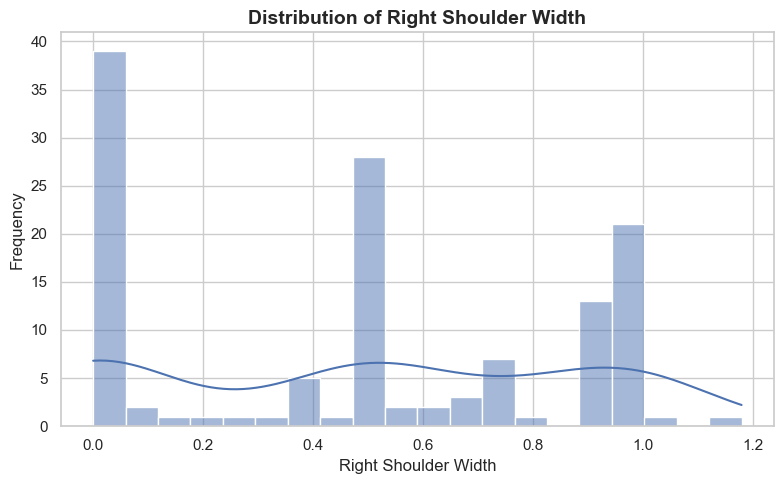

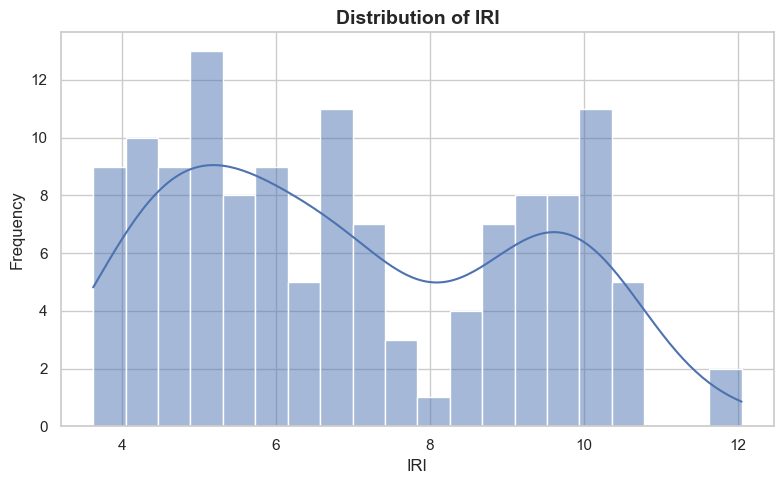

In [38]:
# ============================================================
# STEP 11: HISTOGRAMS + KDE
# ============================================================

plot_variables = [
    "V85 Speed",
    "Gradient",
    "Radius of Curve",
    "Carriageway Width",
    "Left Shoulder Width",
    "Right Shoulder Width",
    "IRI"
]

for variable in plot_variables:

    plt.figure(figsize=(8, 5))

    sns.histplot(
        data=df,
        x=variable,
        kde=True,
        bins=20
    )

    plt.title(
        f"Distribution of {variable}",
        fontsize=14,
        fontweight="bold"
    )

    plt.xlabel(variable)
    plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()

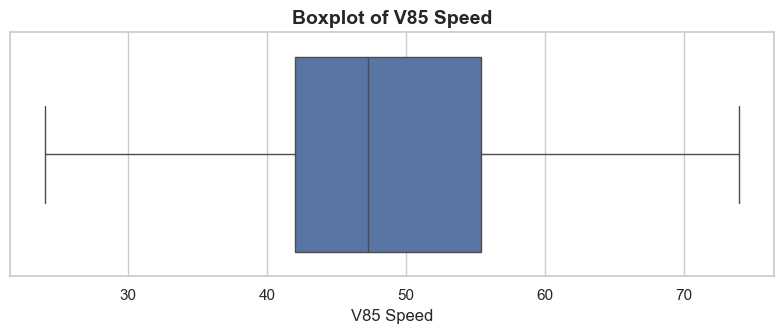

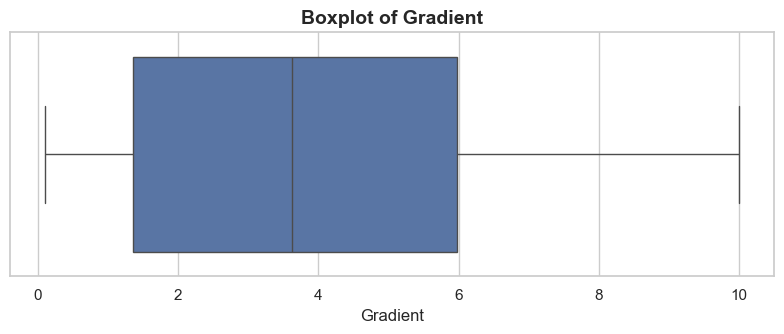

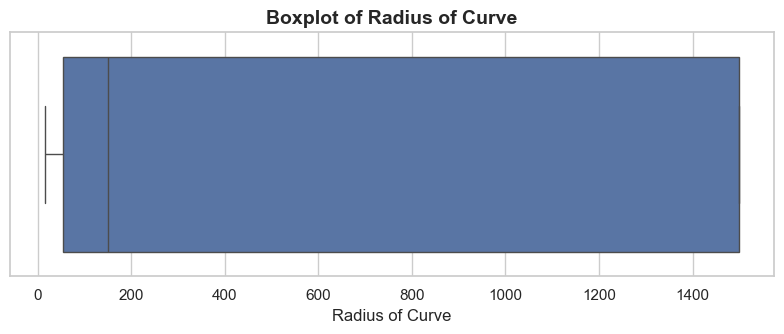

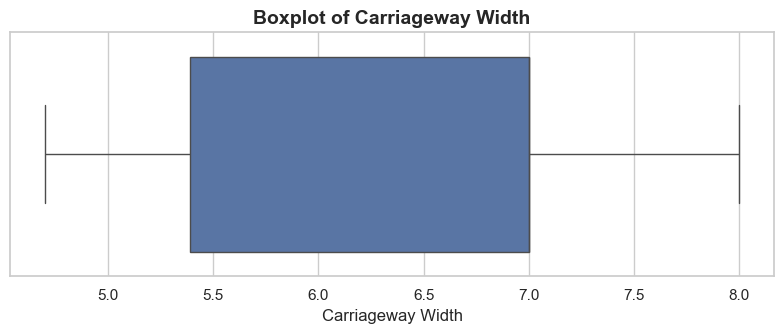

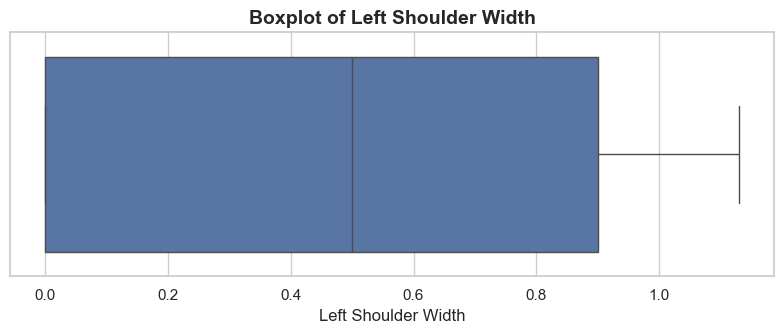

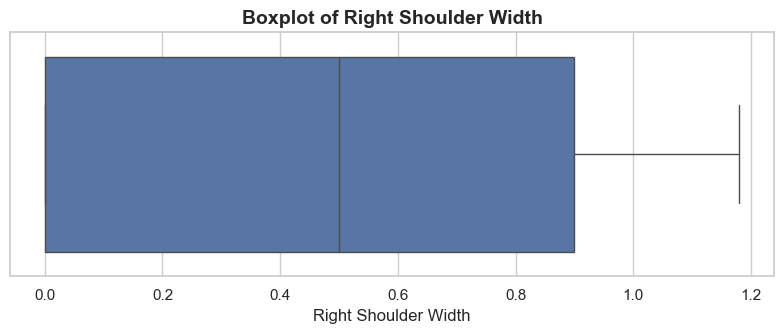

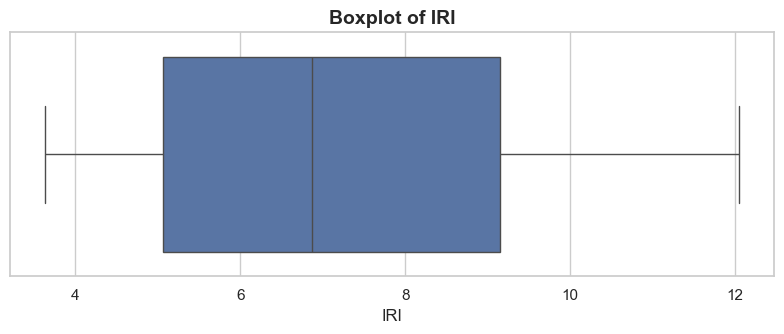

In [39]:
# ============================================================
# STEP 12: BOXPLOTS
# ============================================================

for variable in plot_variables:

    plt.figure(figsize=(8, 3.5))

    sns.boxplot(
        data=df,
        x=variable
    )

    plt.title(
        f"Boxplot of {variable}",
        fontsize=14,
        fontweight="bold"
    )

    plt.xlabel(variable)

    plt.tight_layout()
    plt.show()

In [40]:
# ============================================================
# STEP 13: SHOULDER TYPE COUNTS
# ============================================================

print("Left Shoulder Type:")
display(
    df["Left Shoulder Type"]
    .value_counts()
    .to_frame("Count")
)

print("\nRight Shoulder Type:")
display(
    df["Right Shoulder Type"]
    .value_counts()
    .to_frame("Count")
)

Left Shoulder Type:


,Count
Left Shoulder Type,
Gravel,57
Absent,41
Paved,32



Right Shoulder Type:


,Count
Right Shoulder Type,
Gravel,49
Paved,42
Absent,39


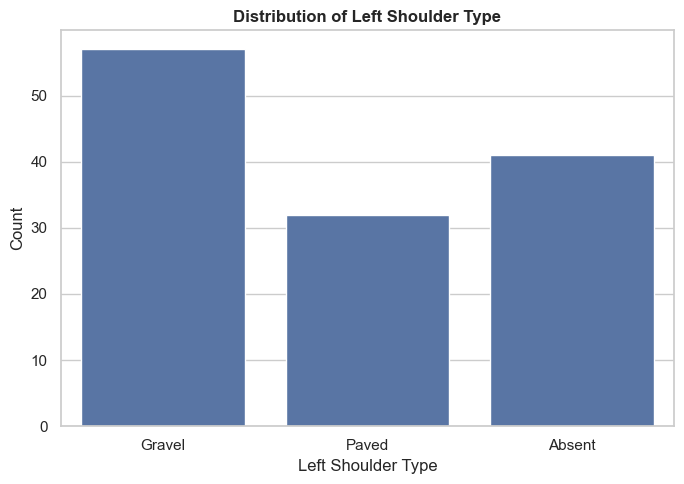

In [41]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Left Shoulder Type"
)

plt.title(
    "Distribution of Left Shoulder Type",
    fontweight="bold"
)

plt.xlabel("Left Shoulder Type")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

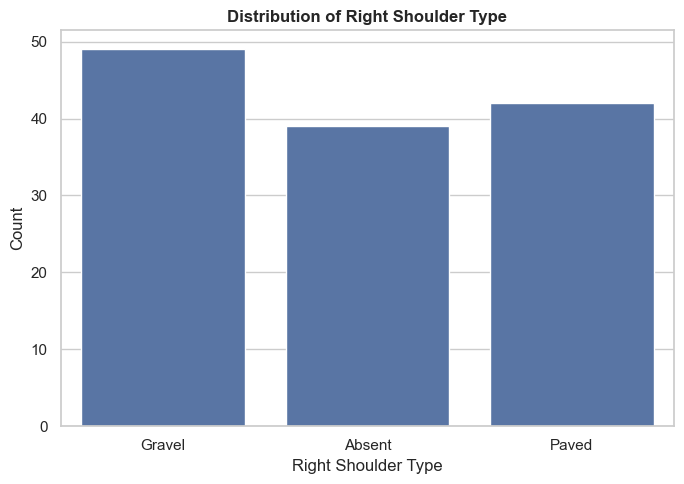

In [42]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Right Shoulder Type"
)

plt.title(
    "Distribution of Right Shoulder Type",
    fontweight="bold"
)

plt.xlabel("Right Shoulder Type")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

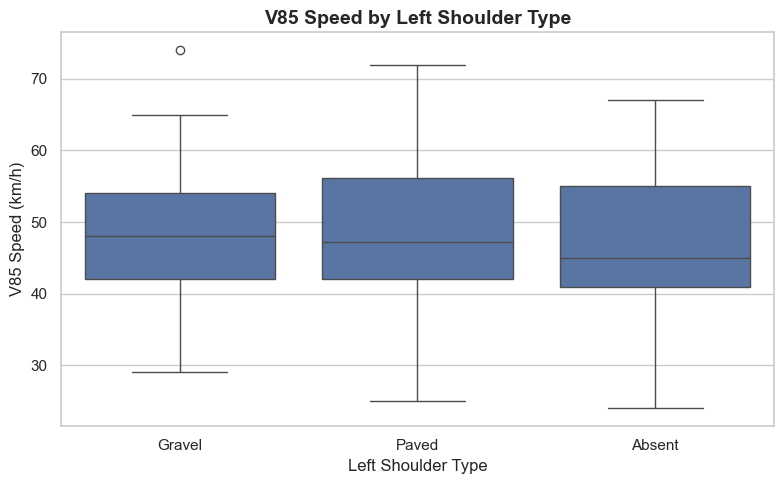

In [43]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Left Shoulder Type",
    y="V85 Speed"
)

plt.title(
    "V85 Speed by Left Shoulder Type",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Left Shoulder Type")
plt.ylabel("V85 Speed (km/h)")

plt.tight_layout()
plt.show()

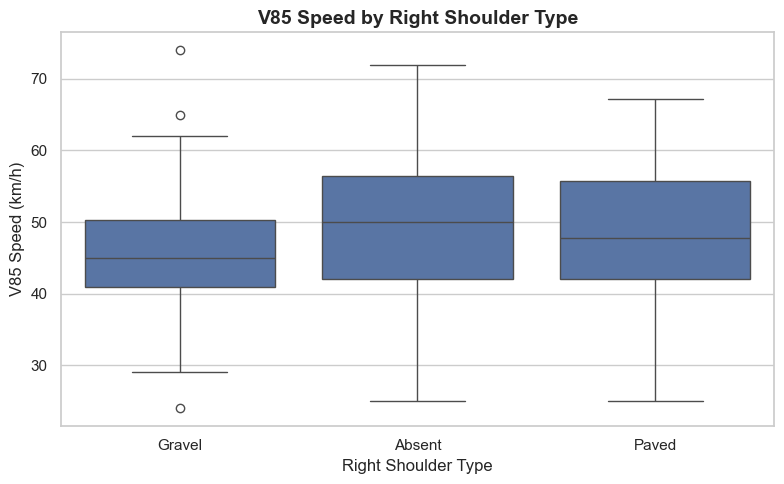

In [44]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Right Shoulder Type",
    y="V85 Speed"
)

plt.title(
    "V85 Speed by Right Shoulder Type",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Right Shoulder Type")
plt.ylabel("V85 Speed (km/h)")

plt.tight_layout()
plt.show()

In [45]:
# ============================================================
# STEP 16: PEARSON CORRELATION MATRIX
# ============================================================

correlation_variables = [
    "V85 Speed",
    "Gradient",
    "Radius of Curve",
    "Carriageway Width",
    "Left Shoulder Width",
    "Right Shoulder Width",
    "IRI"
]

corr_matrix = df[correlation_variables].corr()

display(corr_matrix.round(3))

,V85 Speed,Gradient,Radius of Curve,Carriageway Width,Left Shoulder Width,Right Shoulder Width,IRI
V85 Speed,1.000,-0.009,0.469,0.077,0.073,0.002,0.024
Gradient,-0.009,1.000,-0.150,-0.175,-0.211,-0.221,0.016
Radius of Curve,0.469,-0.150,1.000,0.039,0.213,0.070,-0.061
Carriageway Width,0.077,-0.175,0.039,1.000,0.019,-0.242,0.582
Left Shoulder Width,0.073,-0.211,0.213,0.019,1.000,0.247,-0.211
Right Shoulder Width,0.002,-0.221,0.070,-0.242,0.247,1.000,-0.207
IRI,0.024,0.016,-0.061,0.582,-0.211,-0.207,1.000


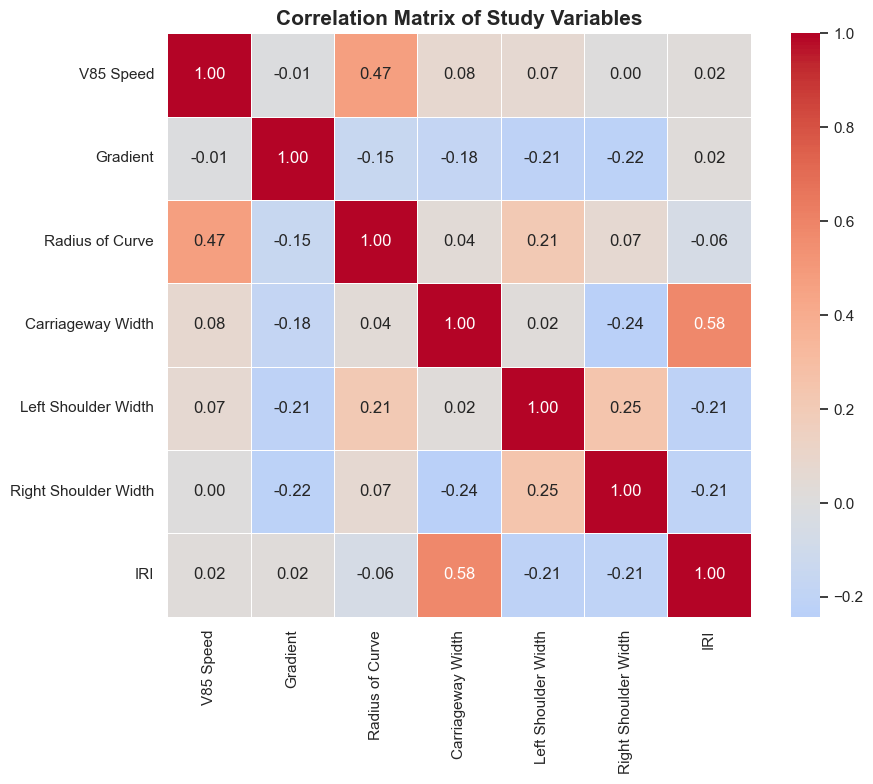

In [46]:
# ============================================================
# CORRELATION HEATMAP
# ============================================================

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5
)

plt.title(
    "Correlation Matrix of Study Variables",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

In [47]:
# ============================================================
# CORRELATION WITH V85 SPEED
# ============================================================

v85_correlation = (
    corr_matrix["V85 Speed"]
    .drop("V85 Speed")
    .sort_values(ascending=False)
)

v85_corr_table = pd.DataFrame({
    "Variable": v85_correlation.index,
    "Correlation with V85": v85_correlation.values
})

display(v85_corr_table.round(3))

,Variable,Correlation with V85
0,Radius of Curve,0.469
1,Carriageway Width,0.077
2,Left Shoulder Width,0.073
3,IRI,0.024
4,Right Shoulder Width,0.002
5,Gradient,-0.009


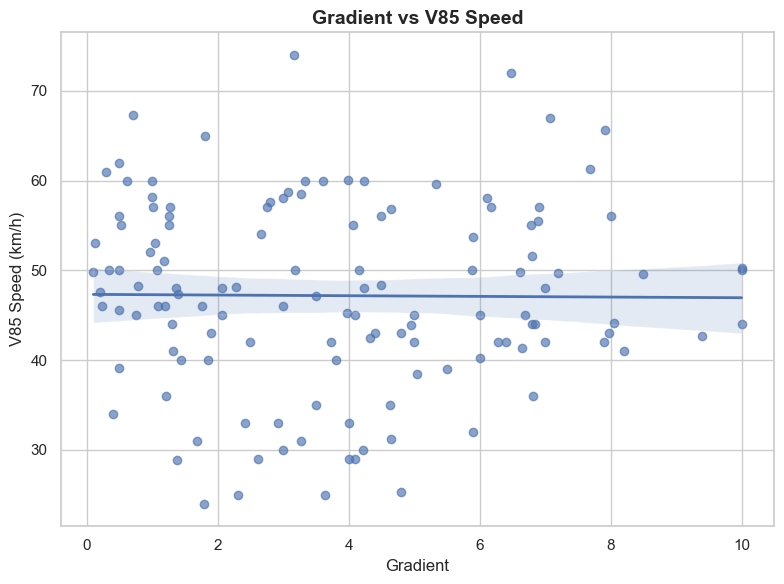

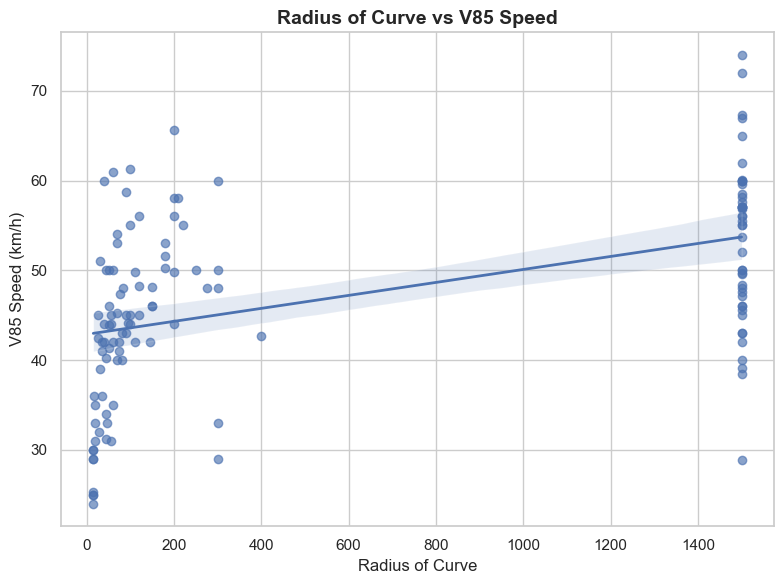

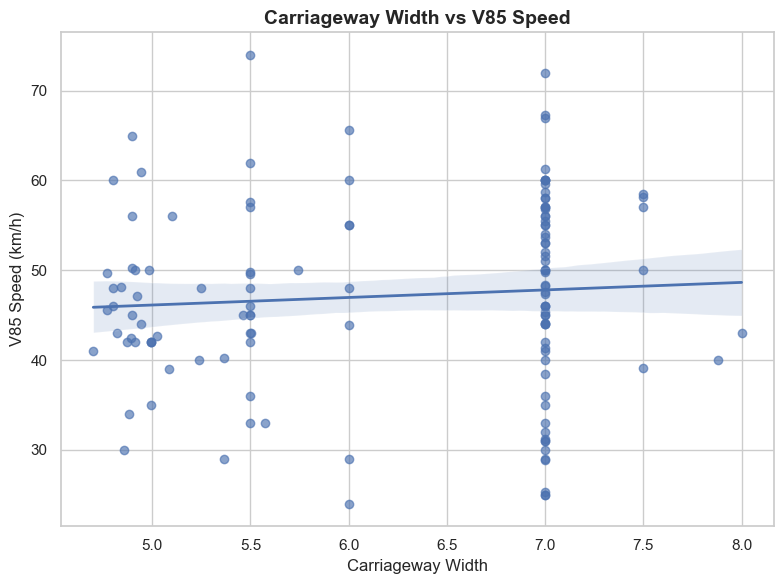

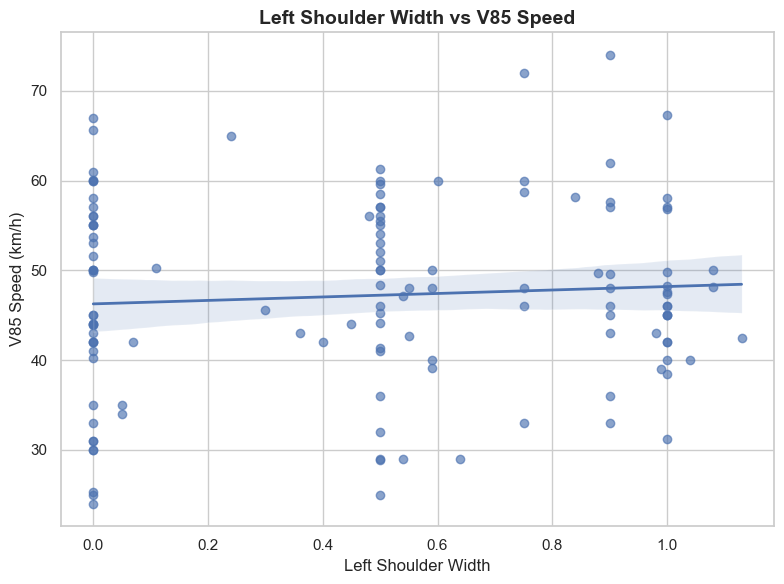

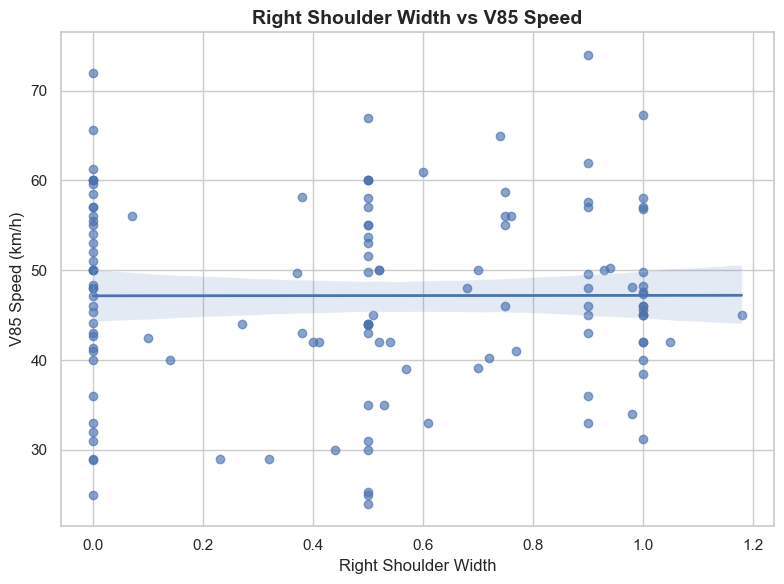

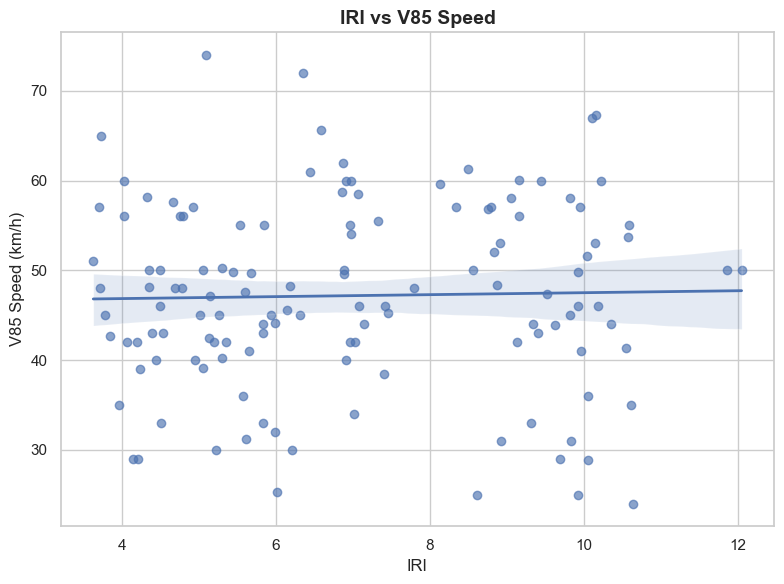

In [55]:
# ============================================================
# ALL ORIGINAL PREDICTORS VS V85
# ============================================================

relationship_variables = [
    "Gradient",
    "Radius of Curve",
    "Carriageway Width",
    "Left Shoulder Width",
    "Right Shoulder Width",
    "IRI"
]

for variable in relationship_variables:

    plt.figure(figsize=(8, 6))

    sns.regplot(
        data=df,
        x=variable,
        y="V85 Speed",
        scatter_kws={"alpha": 0.65},
        line_kws={"linewidth": 2}
    )

    plt.title(
        f"{variable} vs V85 Speed",
        fontsize=14,
        fontweight="bold"
    )

    plt.xlabel(variable)
    plt.ylabel("V85 Speed (km/h)")

    plt.tight_layout()
    plt.show()

In [56]:
# ============================================================
# STEP 26: INITIAL DATASET FOR VIF
# Includes shoulder type + separate shoulder widths
# ============================================================

vif_data_initial = df[
    [
        "Gradient",
        "Radius of Curve",
        "Carriageway Width",
        "Left Shoulder Width",
        "Right Shoulder Width",
        "IRI",
        "Left Shoulder Type",
        "Right Shoulder Type"
    ]
].copy()

vif_data_initial = pd.get_dummies(
    vif_data_initial,
    columns=[
        "Left Shoulder Type",
        "Right Shoulder Type"
    ],
    drop_first=True,
    dtype=int
)

display(vif_data_initial.head())

print(vif_data_initial.columns.tolist())

,Gradient,Radius of Curve,Carriageway Width,Left Shoulder Width,Right Shoulder Width,IRI,Left Shoulder Type_Gravel,Left Shoulder Type_Paved,Right Shoulder Type_Gravel,Right Shoulder Type_Paved
0,1.27,1500.0,5.5,0.9,0.9,3.70,1,0,1,0
1,2.92,46.0,5.5,0.9,0.9,4.51,1,0,1,0
2,7.97,1500.0,5.5,0.9,0.9,4.39,1,0,1,0
3,2.07,1500.0,5.5,0.9,0.9,4.69,1,0,1,0
4,1.21,16.0,5.5,0.9,0.9,5.57,1,0,1,0


['Gradient', 'Radius of Curve', 'Carriageway Width', 'Left Shoulder Width', 'Right Shoulder Width', 'IRI', 'Left Shoulder Type_Gravel', 'Left Shoulder Type_Paved', 'Right Shoulder Type_Gravel', 'Right Shoulder Type_Paved']


In [57]:
# ============================================================
# STEP 27: INITIAL VIF CHECK
# ============================================================

X_vif_initial = vif_data_initial.astype(float)

X_vif_initial_const = sm.add_constant(
    X_vif_initial
)

vif_initial = pd.DataFrame()

vif_initial["Feature"] = (
    X_vif_initial_const.columns
)

vif_initial["VIF"] = [
    variance_inflation_factor(
        X_vif_initial_const.values,
        i
    )
    for i in range(X_vif_initial_const.shape[1])
]

display(vif_initial.round(3))

,Feature,VIF
0,const,92.656
1,Gradient,1.216
2,Radius of Curve,1.092
3,Carriageway Width,1.834
4,Left Shoulder Width,4.664
5,Right Shoulder Width,4.413
6,IRI,1.805
7,Left Shoulder Type_Gravel,6.230
8,Left Shoulder Type_Paved,4.982
9,Right Shoulder Type_Gravel,5.234


In [58]:
vif_initial_sorted = (
    vif_initial[
        vif_initial["Feature"] != "const"
    ]
    .sort_values(
        "VIF",
        ascending=False
    )
    .reset_index(drop=True)
)

display(vif_initial_sorted.round(3))

,Feature,VIF
0,Left Shoulder Type_Gravel,6.230
1,Right Shoulder Type_Paved,5.714
2,Right Shoulder Type_Gravel,5.234
3,Left Shoulder Type_Paved,4.982
4,Left Shoulder Width,4.664
5,Right Shoulder Width,4.413
6,Carriageway Width,1.834
7,IRI,1.805
8,Gradient,1.216
9,Radius of Curve,1.092


In [59]:
# ============================================================
# SHOULDER VARIABLE CORRELATION
# ============================================================

shoulder_columns = [
    col
    for col in vif_data_initial.columns
    if "Shoulder" in col
]

shoulder_corr = (
    vif_data_initial[shoulder_columns]
    .corr()
)

display(shoulder_corr.round(3))

,Left Shoulder Width,Right Shoulder Width,Left Shoulder Type_Gravel,Left Shoulder Type_Paved,Right Shoulder Type_Gravel,Right Shoulder Type_Paved
Left Shoulder Width,1.000,0.247,0.516,0.295,0.284,-0.309
Right Shoulder Width,0.247,1.000,0.123,-0.206,0.446,0.347
Left Shoulder Type_Gravel,0.516,0.123,1.000,-0.505,0.400,-0.412
Left Shoulder Type_Paved,0.295,-0.206,-0.505,1.000,-0.223,-0.089
Right Shoulder Type_Gravel,0.284,0.446,0.400,-0.223,1.000,-0.537
Right Shoulder Type_Paved,-0.309,0.347,-0.412,-0.089,-0.537,1.000


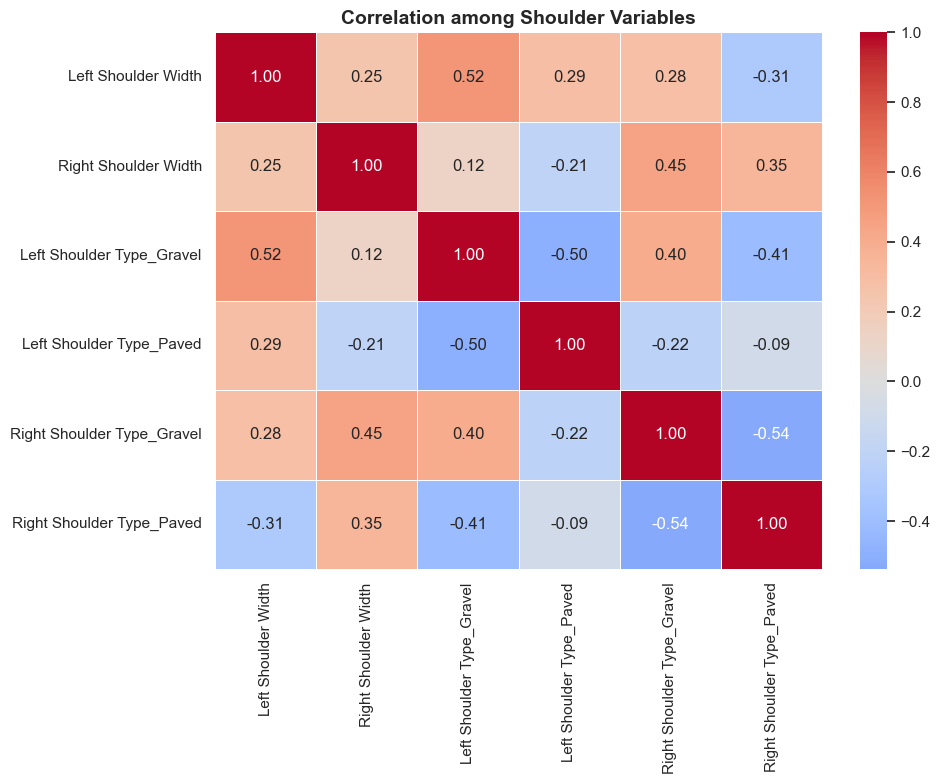

In [60]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    shoulder_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title(
    "Correlation among Shoulder Variables",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

In [61]:
# ============================================================
# STEP 29: CREATE AVERAGE SHOULDER WIDTH
# ============================================================

df["Average Shoulder Width"] = (
    df["Left Shoulder Width"]
    + df["Right Shoulder Width"]
) / 2

display(
    df[
        [
            "Left Shoulder Width",
            "Right Shoulder Width",
            "Average Shoulder Width"
        ]
    ].head(10)
)

,Left Shoulder Width,Right Shoulder Width,Average Shoulder Width
0,0.9,0.9,0.9
1,0.9,0.9,0.9
2,0.9,0.9,0.9
3,0.9,0.9,0.9
4,0.9,0.9,0.9
5,0.9,0.9,0.9
6,0.9,0.9,0.9
7,0.9,0.9,0.9
8,0.9,0.9,0.9
9,0.9,0.9,0.9


In [62]:
print(
    df["Average Shoulder Width"]
    .describe()
)

count    130.000000
mean       0.479500
std        0.307118
min        0.000000
25%        0.250000
50%        0.297500
75%        0.750000
max        1.030000
Name: Average Shoulder Width, dtype: float64


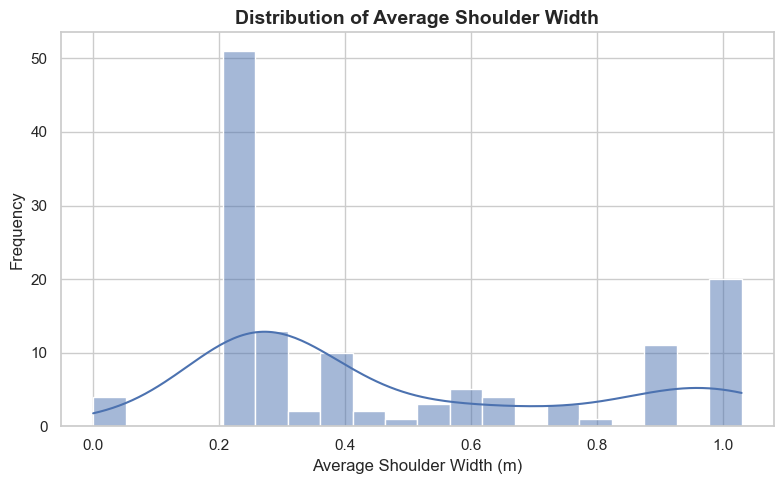

In [63]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="Average Shoulder Width",
    kde=True,
    bins=20
)

plt.title(
    "Distribution of Average Shoulder Width",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Average Shoulder Width (m)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

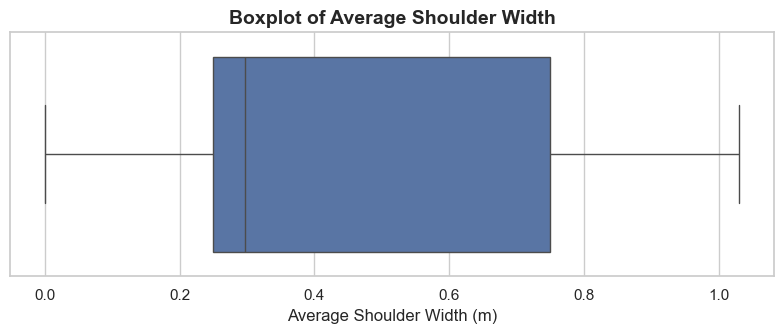

In [64]:
plt.figure(figsize=(8, 3.5))

sns.boxplot(
    data=df,
    x="Average Shoulder Width"
)

plt.title(
    "Boxplot of Average Shoulder Width",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Average Shoulder Width (m)")

plt.tight_layout()
plt.show()

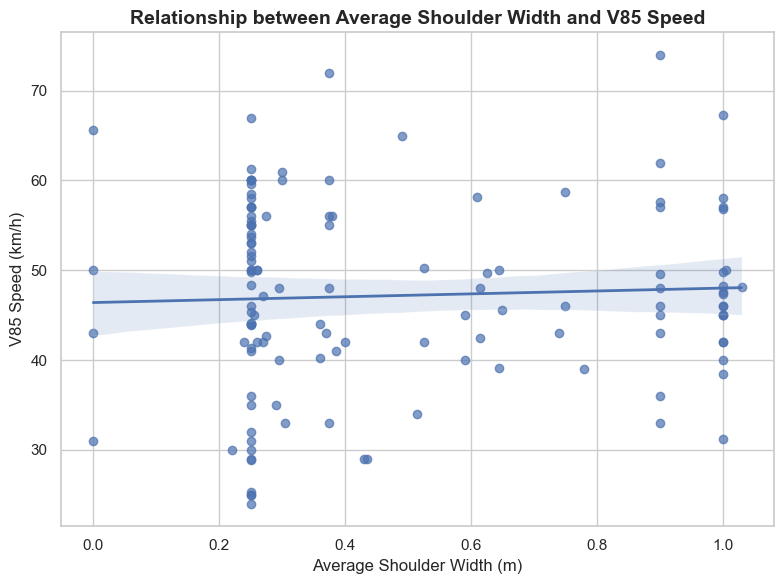

In [65]:
plt.figure(figsize=(8, 6))

sns.regplot(
    data=df,
    x="Average Shoulder Width",
    y="V85 Speed",
    scatter_kws={"alpha": 0.7},
    line_kws={"linewidth": 2}
)

plt.title(
    "Relationship between Average Shoulder Width and V85 Speed",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Average Shoulder Width (m)")
plt.ylabel("V85 Speed (km/h)")

plt.tight_layout()
plt.show()

In [66]:
# ============================================================
# STEP 33: FINAL MODEL CORRELATION MATRIX
# ============================================================

final_corr_variables = [
    "V85 Speed",
    "Gradient",
    "Radius of Curve",
    "Carriageway Width",
    "Average Shoulder Width",
    "IRI"
]

final_corr = (
    df[final_corr_variables]
    .corr()
)

display(final_corr.round(3))

,V85 Speed,Gradient,Radius of Curve,Carriageway Width,Average Shoulder Width,IRI
V85 Speed,1.000,-0.009,0.469,0.077,0.048,0.024
Gradient,-0.009,1.000,-0.150,-0.175,-0.274,0.016
Radius of Curve,0.469,-0.150,1.000,0.039,0.180,-0.061
Carriageway Width,0.077,-0.175,0.039,1.000,-0.139,0.582
Average Shoulder Width,0.048,-0.274,0.180,-0.139,1.000,-0.264
IRI,0.024,0.016,-0.061,0.582,-0.264,1.000


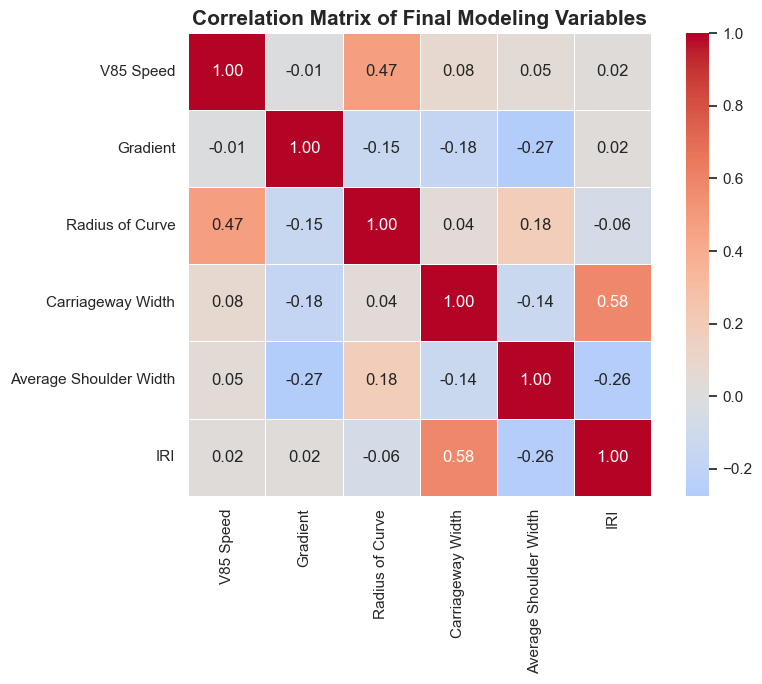

In [67]:
plt.figure(figsize=(9, 7))

sns.heatmap(
    final_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5
)

plt.title(
    "Correlation Matrix of Final Modeling Variables",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

In [68]:
final_v85_corr = (
    final_corr["V85 Speed"]
    .drop("V85 Speed")
    .sort_values(ascending=False)
)

final_v85_corr_table = pd.DataFrame({
    "Variable": final_v85_corr.index,
    "Pearson Correlation with V85": final_v85_corr.values
})

display(final_v85_corr_table.round(3))

,Variable,Pearson Correlation with V85
0,Radius of Curve,0.469
1,Carriageway Width,0.077
2,Average Shoulder Width,0.048
3,IRI,0.024
4,Gradient,-0.009


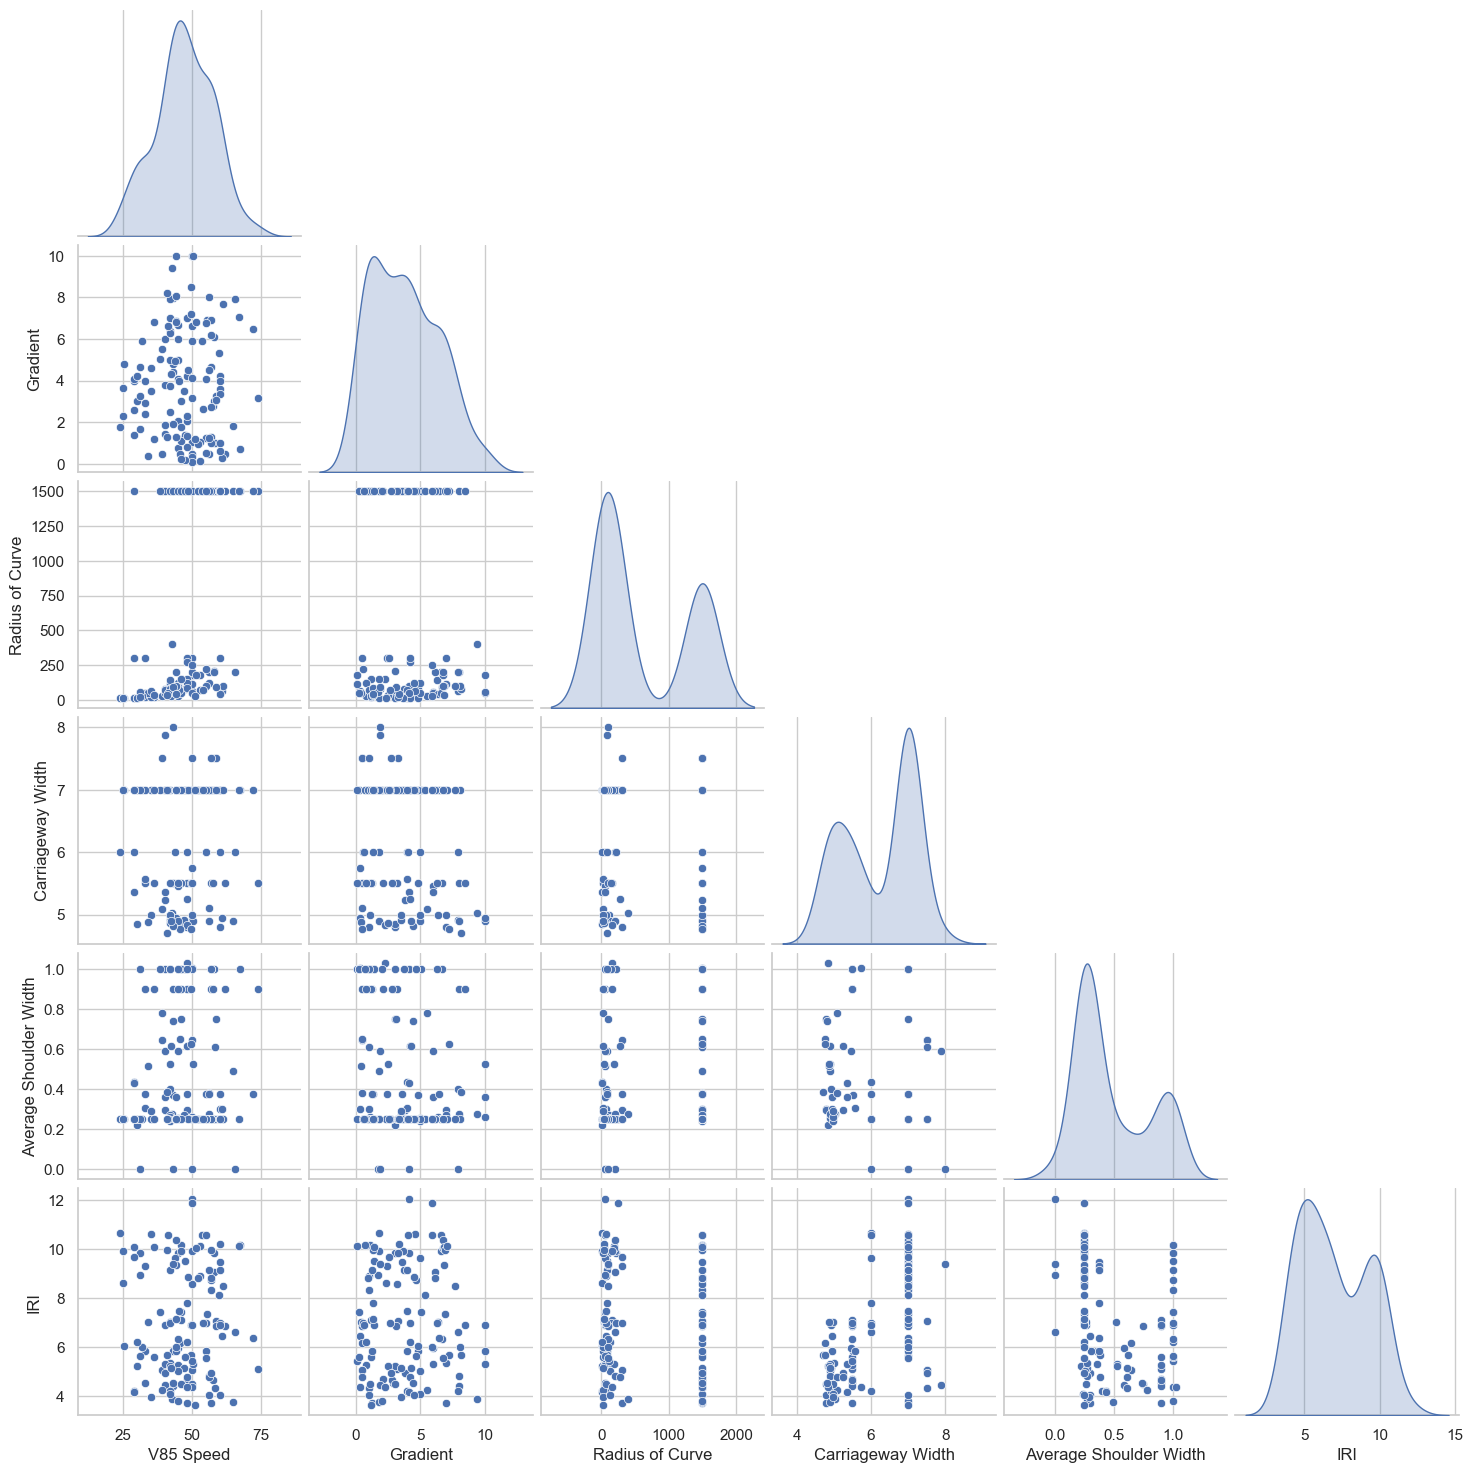

In [69]:
# ============================================================
# STEP 35: PAIRWISE RELATIONSHIP PLOT
# ============================================================

sns.pairplot(
    df[final_corr_variables],
    diag_kind="kde",
    corner=True
)

plt.show()

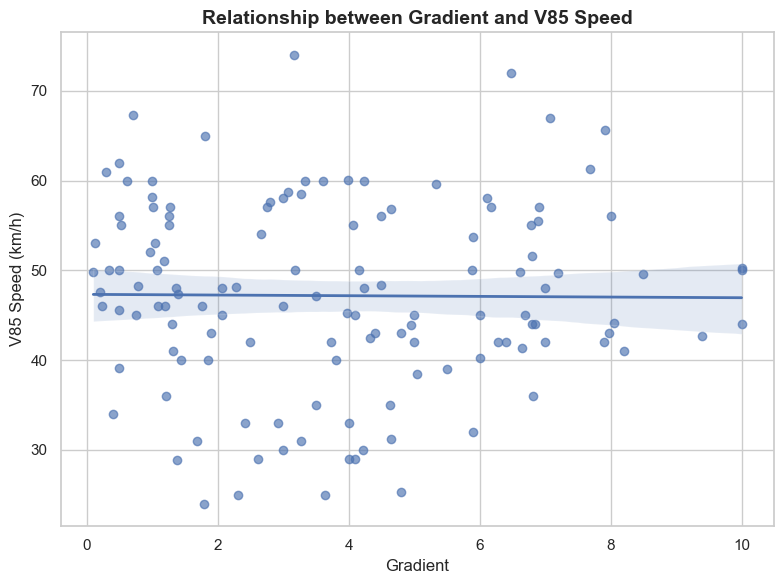

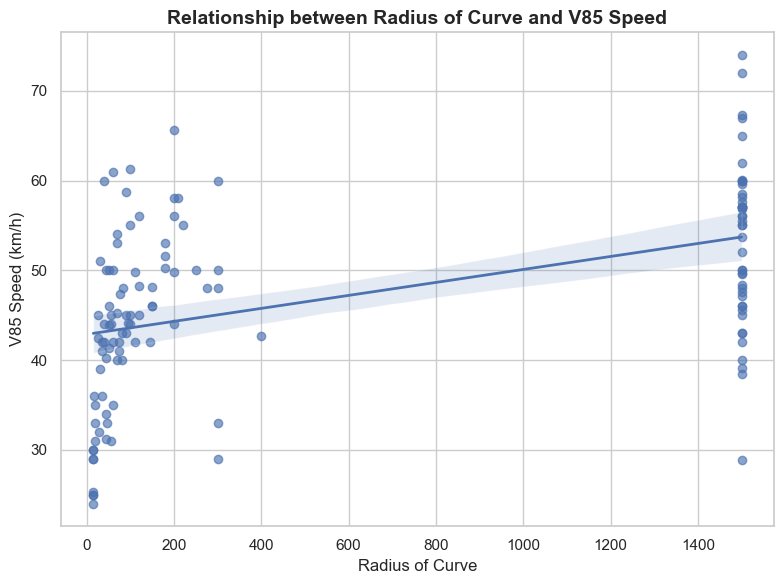

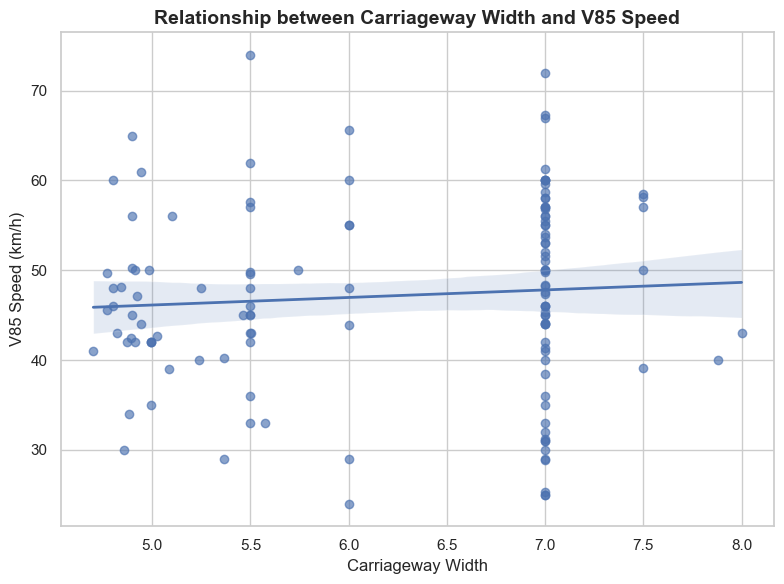

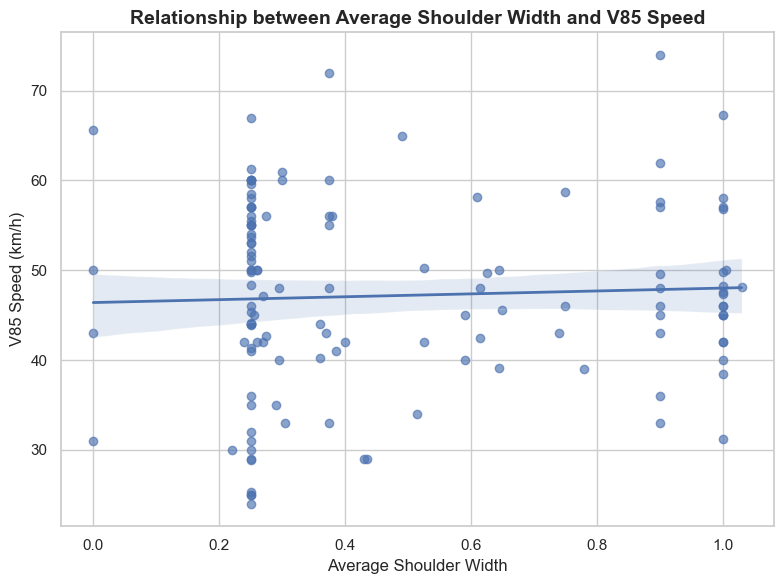

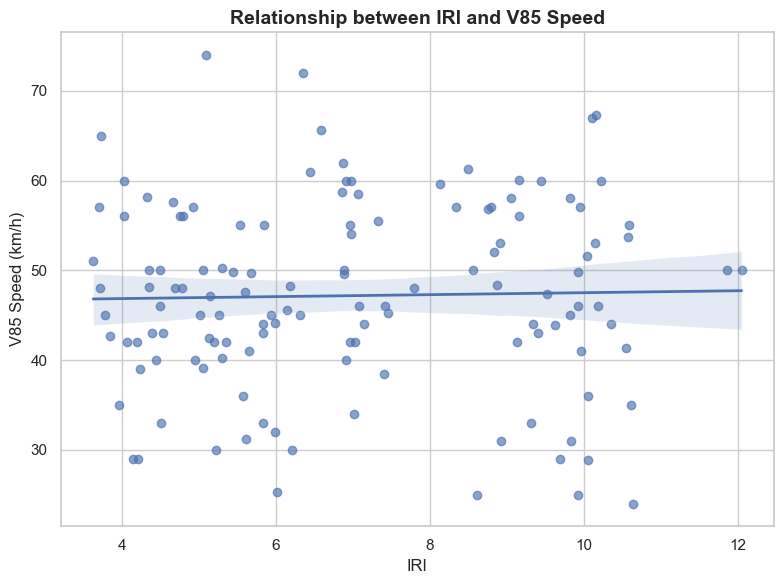

In [70]:
# ============================================================
# FINAL PREDICTORS VS V85
# ============================================================

final_predictors = [
    "Gradient",
    "Radius of Curve",
    "Carriageway Width",
    "Average Shoulder Width",
    "IRI"
]

for variable in final_predictors:

    plt.figure(figsize=(8, 6))

    sns.regplot(
        data=df,
        x=variable,
        y="V85 Speed",
        scatter_kws={"alpha": 0.65},
        line_kws={"linewidth": 2}
    )

    plt.title(
        f"Relationship between {variable} and V85 Speed",
        fontsize=14,
        fontweight="bold"
    )

    plt.xlabel(variable)
    plt.ylabel("V85 Speed (km/h)")

    plt.tight_layout()
    plt.show()

In [71]:
# ============================================================
# STEP 37: FINAL FEATURE SET
# ============================================================

final_features = [
    "Gradient",
    "Radius of Curve",
    "Carriageway Width",
    "Average Shoulder Width",
    "IRI"
]

X = df[final_features].copy()

y = df["V85 Speed"].copy()

print("Final predictors:")
print(X.columns.tolist())

print("\nX shape:", X.shape)
print("y shape:", y.shape)

display(X.head())

Final predictors:
['Gradient', 'Radius of Curve', 'Carriageway Width', 'Average Shoulder Width', 'IRI']

X shape: (130, 5)
y shape: (130,)


,Gradient,Radius of Curve,Carriageway Width,Average Shoulder Width,IRI
0,1.27,1500.0,5.5,0.9,3.70
1,2.92,46.0,5.5,0.9,4.51
2,7.97,1500.0,5.5,0.9,4.39
3,2.07,1500.0,5.5,0.9,4.69
4,1.21,16.0,5.5,0.9,5.57


In [72]:
# ============================================================
# STEP 38: FINAL VIF CHECK
# ============================================================

X_vif_final = X.astype(float)

X_vif_final_const = sm.add_constant(
    X_vif_final
)

vif_final = pd.DataFrame()

vif_final["Feature"] = (
    X_vif_final_const.columns
)

vif_final["VIF"] = [
    variance_inflation_factor(
        X_vif_final_const.values,
        i
    )
    for i in range(X_vif_final_const.shape[1])
]

display(vif_final.round(3))

,Feature,VIF
0,const,64.700
1,Gradient,1.156
2,Radius of Curve,1.051
3,Carriageway Width,1.604
4,Average Shoulder Width,1.192
5,IRI,1.610


In [73]:
final_vif_table = (
    vif_final[
        vif_final["Feature"] != "const"
    ]
    .sort_values(
        by="VIF",
        ascending=False
    )
    .reset_index(drop=True)
)

display(final_vif_table.round(3))

,Feature,VIF
0,IRI,1.610
1,Carriageway Width,1.604
2,Average Shoulder Width,1.192
3,Gradient,1.156
4,Radius of Curve,1.051


In [74]:
# ============================================================
# STEP 39: INITIAL VS FINAL VIF
# ============================================================

print("=" * 75)
print("INITIAL VIF")
print("Separate Shoulder Widths + Shoulder Types + IRI")
print("=" * 75)

display(vif_initial_sorted.round(3))


print("\n" + "=" * 75)
print("FINAL VIF")
print("Average Shoulder Width + No Shoulder Type + IRI")
print("=" * 75)

display(final_vif_table.round(3))

INITIAL VIF
Separate Shoulder Widths + Shoulder Types + IRI


,Feature,VIF
0,Left Shoulder Type_Gravel,6.230
1,Right Shoulder Type_Paved,5.714
2,Right Shoulder Type_Gravel,5.234
3,Left Shoulder Type_Paved,4.982
4,Left Shoulder Width,4.664
5,Right Shoulder Width,4.413
6,Carriageway Width,1.834
7,IRI,1.805
8,Gradient,1.216
9,Radius of Curve,1.092



FINAL VIF
Average Shoulder Width + No Shoulder Type + IRI


,Feature,VIF
0,IRI,1.610
1,Carriageway Width,1.604
2,Average Shoulder Width,1.192
3,Gradient,1.156
4,Radius of Curve,1.051
